# 1. Data Analysis & Preprocessing

This notebook explicitly demonstrates the Exploratory Data Analysis (EDA) and Data Preprocessing (Missing Values, Outliers, Encoding, Scaling) performed on the Health Insurance Cross-Sell Dataset before feeding it into our Machine Learning models.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

if os.path.exists('data/raw_data.csv'):
    df = pd.read_csv('data/raw_data.csv')
elif os.path.exists('../data/raw_data.csv'):
    df = pd.read_csv('../data/raw_data.csv')
else:
    raise FileNotFoundError('Cannot find raw_data.csv')
    
print("Data Shape:", df.shape)
display(df.head())

Data Shape: (381109, 12)


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


## 1.1 Exploratory Data Analysis (EDA) & Visualizations

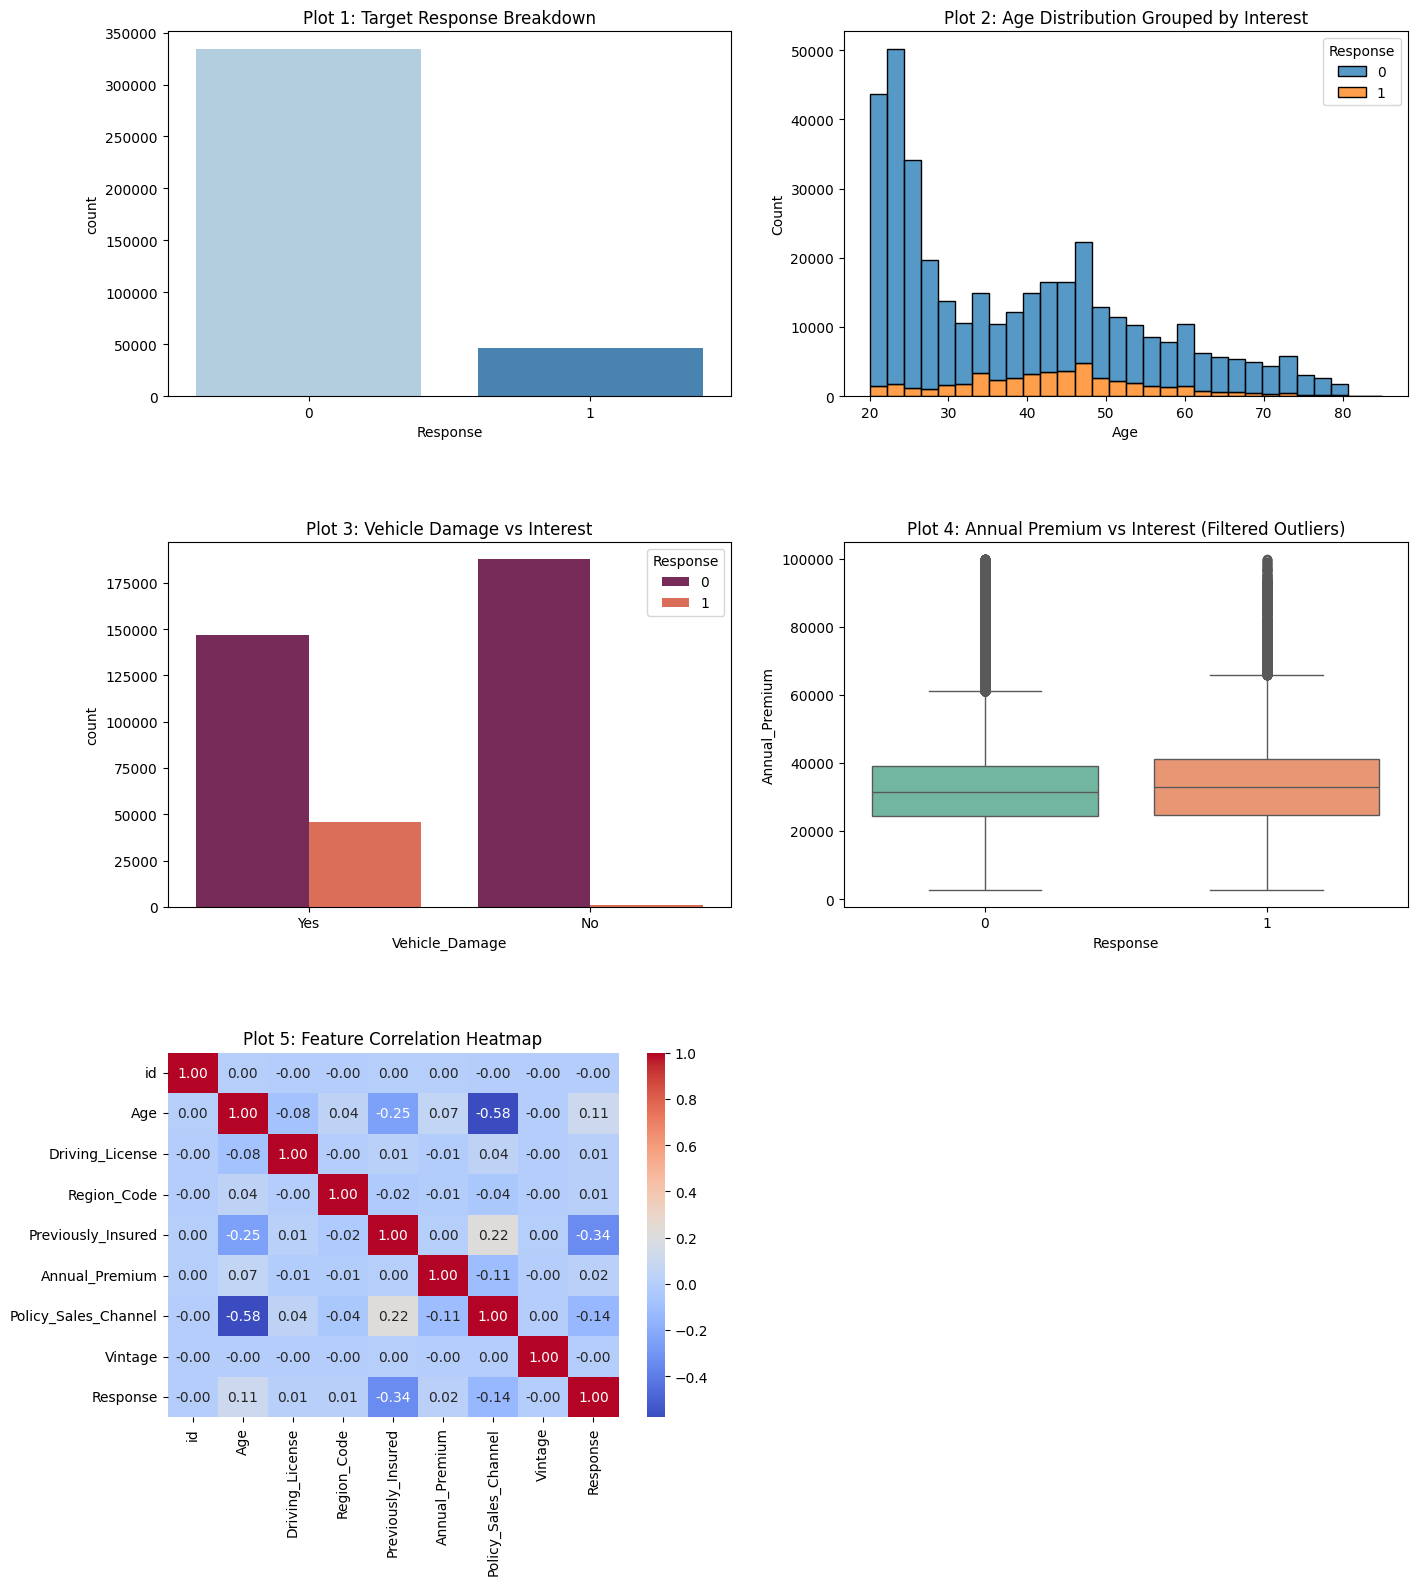

In [2]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
plt.subplots_adjust(hspace=0.4)

# Plot 1: Target Distribution
sns.countplot(x='Response', data=df, ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title("Plot 1: Target Response Breakdown")

# Plot 2: Age Distribution vs Response
sns.histplot(data=df, x='Age', hue='Response', bins=30, multiple='stack', ax=axes[0, 1])
axes[0, 1].set_title("Plot 2: Age Distribution Grouped by Interest")

# Plot 3: Vehicle Damage Impact
sns.countplot(x='Vehicle_Damage', hue='Response', data=df, ax=axes[1, 0], palette='rocket')
axes[1, 0].set_title("Plot 3: Vehicle Damage vs Interest")

# Plot 4: Annual Premium Distribution
sns.boxplot(x='Response', y='Annual_Premium', data=df[df['Annual_Premium'] < 100000], ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title("Plot 4: Annual Premium vs Interest (Filtered Outliers)")

# Plot 5: Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2, 0])
axes[2, 0].set_title("Plot 5: Feature Correlation Heatmap")

axes[2, 1].remove() # Blank out the last subplot space
plt.show()


## 1.2 Data Preprocessing (Step-by-Step)
Data requires heavy preprocessing to align with clustering algorithms mathematically.

### 1.2.1 Handling Missing Values
We impute numeric columns with their **Median** to avoid outlier bias, and categorical columns with their **Mode**.

In [3]:
df_clean = df.copy()
if 'id' in df_clean.columns:
    df_clean.drop('id', axis=1, inplace=True)

for col in ['Age', 'Annual_Premium', 'Vintage']:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)
    
for col in ['Gender', 'Vehicle_Age', 'Vehicle_Damage']:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
    
print('Missing values handled successfully.')

Missing values handled successfully.


### 1.2.2 Outlier Treatment (IQR Clipping)
The `Annual_Premium` feature contains extreme outliers (up to 500k) which heavily distort distance calculations in clustering. We cap them mathematically at the Upper Limit via IQR.

In [4]:
Q1 = df_clean['Annual_Premium'].quantile(0.25)
Q3 = df_clean['Annual_Premium'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
df_clean['Annual_Premium'] = df_clean['Annual_Premium'].clip(lower=lower, upper=upper)

print('Outliers clipped successfully.')

Outliers clipped successfully.


### 1.2.3 Categorical Encoding
Clustering algorithms strictly require numerical inputs. We use `LabelEncoder` for strings.

In [5]:
from sklearn.preprocessing import LabelEncoder

vehicle_age_map = {'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 2}
df_clean['Vehicle_Age'] = df_clean['Vehicle_Age'].map(vehicle_age_map).fillna(0)

le_gender = LabelEncoder()
df_clean['Gender'] = le_gender.fit_transform(df_clean['Gender'])

le_damage = LabelEncoder()
df_clean['Vehicle_Damage'] = le_damage.fit_transform(df_clean['Vehicle_Damage'])

print('Categorical variables encoded.')

Categorical variables encoded.


### 1.2.4 Feature Scaling
Features like `Age` (20-80) and `Annual_Premium` operate on vastly different scales. We use `StandardScaler` to force all features onto a standard zero-mean variance space.

In [6]:
from sklearn.preprocessing import StandardScaler

if 'Response' in df_clean.columns:
    X_raw = df_clean.drop('Response', axis=1)
    y_target = df_clean['Response']
else:
    X_raw = df_clean

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print('Features scaled with StandardScaler.')
print("Final X_scaled shape:", X_scaled.shape)

Features scaled with StandardScaler.
Final X_scaled shape: (381109, 10)


## 1.3 Export Cleaned Data
Finally, we save the completely cleaned dataset (before scaling, to retain readability) to be used by other parts of the project.

In [7]:
out_path = '../data/cleaned_data.csv' if os.path.exists('../data/raw_data.csv') else 'data/cleaned_data.csv'
# We export df_clean which has missing values and outliers handled, and categorical encoded.
df_clean.to_csv(out_path, index=False)
print(f'Cleaned data exported successfully to {out_path}!')

Cleaned data exported successfully to ../data/cleaned_data.csv!
